In [1]:
from pathlib import Path
import sys
import numpy as np
from scipy.signal import correlate, correlation_lags

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "Tx_Waveform_and_Bits").exists() and (path / "10km").exists():
            return path
    raise FileNotFoundError("Could not find the dataset repo root.")

def load_complex_waveform(i_path, q_path):
    return np.loadtxt(i_path) + 1j * np.loadtxt(q_path)

def finddelay(reference, received):
    """FFT cross-correlation equivalent of MATLAB finddelay(reference, received)."""
    corr = correlate(received, reference, mode="full", method="fft")
    lags = correlation_lags(received.size, reference.size, mode="full")
    return int(lags[np.argmax(np.abs(corr))])

REBUILD_DATASET = False
DATASET_NAME = "10km_16QAM_28_3"
M = 16
ROLLOFF = 0.2
SPS = 10
FILTER_SPAN = 10
DECIMATION_FACTOR = 10

repo_root = find_repo_root()
analysis_dir = repo_root / "Use_Cases" / "OFC_Paper_Analysis"
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from utils import qam_mod, raised_cosine_receive_filter

npz_file = analysis_dir / f"{DATASET_NAME}.npz"

if REBUILD_DATASET or not npz_file.exists():
    tx_dir = repo_root / "Tx_Waveform_and_Bits"
    rx_dir = repo_root / "10km" / "16QAM"

    tx_waveform = load_complex_waveform(tx_dir / "16QAM_i.txt", tx_dir / "16QAM_q.txt")
    rx_waveform = load_complex_waveform(rx_dir / "16QAM_28_3_i.txt", rx_dir / "16QAM_28_3_q.txt")
    tx_bits = np.loadtxt(tx_dir / "16QAM_bits.txt", dtype=np.uint8)
    total_tx_symbols = qam_mod(tx_bits, M, unit_power=True)

    delay = finddelay(tx_waveform, rx_waveform)
    rx_waveform = np.roll(rx_waveform, -delay-2)  # Align the waveforms, with a small offset to account for filter delay

    filtered_symbols = raised_cosine_receive_filter(
        rx_waveform,
        rolloff=ROLLOFF,
        sps=SPS,
        filter_span=FILTER_SPAN,
        decimation_factor=DECIMATION_FACTOR,
    )

    rx_symbols = filtered_symbols[FILTER_SPAN:]
    label_symbols = total_tx_symbols[: rx_symbols.size]

    np.savez_compressed(
        npz_file,
        input=rx_symbols.reshape(-1, 1),
        label=label_symbols.reshape(-1, 1),
        tx_bits=tx_bits,
        delay=np.array(delay, dtype=np.int64),
        rolloff=np.array(ROLLOFF),
        sps=np.array(SPS, dtype=np.int64),
        filter_span=np.array(FILTER_SPAN, dtype=np.int64),
        decimation_factor=np.array(DECIMATION_FACTOR, dtype=np.int64),
    )
    print(f"Created {npz_file}")
    print(f"finddelay={delay}, input={rx_symbols.shape}, label={label_symbols.shape}")
else:
    print(f"Using cached dataset: {npz_file}")

Using cached dataset: D:\Users\12651\Downloads\mmWave-AROF-Dataset\Use_Cases\OFC_Paper_Analysis\10km_16QAM_28_3.npz


In [2]:
dataset = np.load(npz_file)

input = dataset["input"]
label = dataset["label"]
tx_bits = dataset["tx_bits"]

print(f"input shape: {input.shape}")
print(f"label shape: {label.shape}")
print(f"tx_bits shape: {tx_bits.shape}")
print(f"finddelay: {int(dataset['delay'])}")

input shape: (99990, 1)
label shape: (99990, 1)
tx_bits shape: (400000,)
finddelay: 51677


In [3]:
### Hyperparameter Configuration ###
# Model hyperparameters
NUM_TAPS = 21
NUM_EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2

# Data parameters
MODULATION_ORDER = 16
TEST_SIZE = 0.3
RANDOM_STATE = 42

print(f"Configuration:")
print(f"  Modulation: {MODULATION_ORDER}QAM")
print(f"  Num Taps: {NUM_TAPS}")
print(f"  Num Epochs: {NUM_EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")

Configuration:
  Modulation: 16QAM
  Num Taps: 21
  Num Epochs: 100
  Batch Size: 256
  Learning Rate: 0.001


In [4]:
### Transmitted bits for BER calculation ###
# Loaded from the generated Python-native .npz dataset above.
expected_bits = int(np.log2(MODULATION_ORDER)) * label.shape[0]
assert tx_bits.size >= expected_bits

print(f"Loaded {len(tx_bits)} transmitted bits from {npz_file.name}")
print(f"First 20 bits: {tx_bits[:20]}")

Loaded 400000 transmitted bits from 10km_16QAM_28_3.npz
First 20 bits: [1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1]


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

import torch.nn as nn
import torch.optim as optim

if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [6]:
# Import all model classes
from mlp_model import MLPEqualizer
from xgboost_model import XGBoostEqualizer
from lstm_model import LSTMEqualizer
from gru_model import GRUEqualizer
from transformer_model import TransformerEqualizer

In [7]:
### Train XGBoost Equalizer ###
print("="*60)
print("Training XGBoost Equalizer")
print("="*60)

xgboost_eq = XGBoostEqualizer(
    num_taps=NUM_TAPS,
    n_estimators=500,
    max_depth=12,  
    learning_rate=0.01,
    random_state=RANDOM_STATE
)

xgboost_results = xgboost_eq.train(input, label, tx_bits, MODULATION_ORDER, test_size=TEST_SIZE, verbose=True)

Training XGBoost Equalizer
Creating sliding window data for XGBoost...
Training XGBoost models...
Training complete.

--- XGBoost Results ---
MSE After EQ:  0.0098
EVM After EQ:  9.92%
R2 After EQ:   0.9902
BER After EQ:  5.818412e-03


In [8]:
### Train MLP Equalizer ###
print("\n" + "="*60)
print("Training MLP Equalizer")
print("="*60)

mlp_eq = MLPEqualizer(
    num_taps=NUM_TAPS,
    hidden_layer_size=HIDDEN_SIZE,
    max_iter=1000,
    random_state=RANDOM_STATE
)

mlp_results = mlp_eq.train(input, label, tx_bits, MODULATION_ORDER, test_size=TEST_SIZE, verbose=True)


Training MLP Equalizer
Creating sliding window data for MLP...
Training MLP model...
Training complete.

--- MLP Results ---
MSE After EQ:  0.0090
EVM After EQ:  9.47%
R2 After EQ:   0.9910
BER After EQ:  1.667167e-05


In [9]:
### Train LSTM Equalizer ###
print("\n" + "="*60)
print("Training LSTM Equalizer")
print("="*60)

lstm_eq = LSTMEqualizer(
    num_taps=NUM_TAPS,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    random_state=RANDOM_STATE
)

lstm_results = lstm_eq.train(input, label, tx_bits, MODULATION_ORDER, test_size=TEST_SIZE, verbose=True)


Training LSTM Equalizer
Using device: cuda
Creating sliding window data for LSTM...
Training LSTM model...
Epoch [10/100], Loss: 0.008599
Epoch [20/100], Loss: 0.007616
Epoch [30/100], Loss: 0.006985
Epoch [40/100], Loss: 0.006596
Epoch [50/100], Loss: 0.005596
Epoch [60/100], Loss: 0.002428
Epoch [70/100], Loss: 0.000270
Epoch [80/100], Loss: 0.000134
Epoch [90/100], Loss: 0.000075
Epoch [100/100], Loss: 0.000046
Training complete.

--- LSTM Results ---
MSE After EQ:  0.0000
EVM After EQ:  0.55%
R2 After EQ:   1.0000
BER After EQ:  8.335834e-06


In [10]:
### Train GRU Equalizer ###
print("\n" + "="*60)
print("Training GRU Equalizer")
print("="*60)

gru_eq = GRUEqualizer(
    num_taps=NUM_TAPS,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    random_state=RANDOM_STATE
)

gru_results = gru_eq.train(input, label, tx_bits, MODULATION_ORDER, test_size=TEST_SIZE, verbose=True)


Training GRU Equalizer
Using device: cuda
Creating sliding window data for GRU...
Training GRU model...
Epoch [10/100], Loss: 0.008327
Epoch [20/100], Loss: 0.008186
Epoch [30/100], Loss: 0.007449
Epoch [40/100], Loss: 0.007156
Epoch [50/100], Loss: 0.006693
Epoch [60/100], Loss: 0.005926
Epoch [70/100], Loss: 0.004933
Epoch [80/100], Loss: 0.003783
Epoch [90/100], Loss: 0.003285
Epoch [100/100], Loss: 0.002752
Training complete.

--- GRU Results ---
MSE After EQ:  0.0042
EVM After EQ:  6.44%
R2 After EQ:   0.9958
BER After EQ:  2.917542e-04


In [11]:
### Train Transformer Equalizer ###
print("\n" + "="*60)
print("Training Transformer Equalizer")
print("="*60)

transformer_eq = TransformerEqualizer(
    num_taps=NUM_TAPS,
    d_model=HIDDEN_SIZE,
    nhead=4,
    num_layers=NUM_LAYERS,
    dim_feedforward=256,
    dropout=0.1,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    random_state=RANDOM_STATE
)

transformer_results = transformer_eq.train(input, label, tx_bits, MODULATION_ORDER, test_size=TEST_SIZE, verbose=True)


Training Transformer Equalizer
Using device: cuda
Creating sliding window data for Transformer...
Training Transformer model...
Epoch [10/100], Loss: 0.004475
Epoch [20/100], Loss: 0.003065
Epoch [30/100], Loss: 0.002407
Epoch [40/100], Loss: 0.001336
Epoch [50/100], Loss: 0.000846
Epoch [60/100], Loss: 0.000617
Epoch [70/100], Loss: 0.000509
Epoch [80/100], Loss: 0.000409
Epoch [90/100], Loss: 0.000331
Epoch [100/100], Loss: 0.000289
Training complete.

--- Transformer Results ---
MSE After EQ:  0.0006
EVM After EQ:  2.39%
R2 After EQ:   0.9994
BER After EQ:  1.667167e-05


Figure saved as 'model_comparison_constellation.pdf'


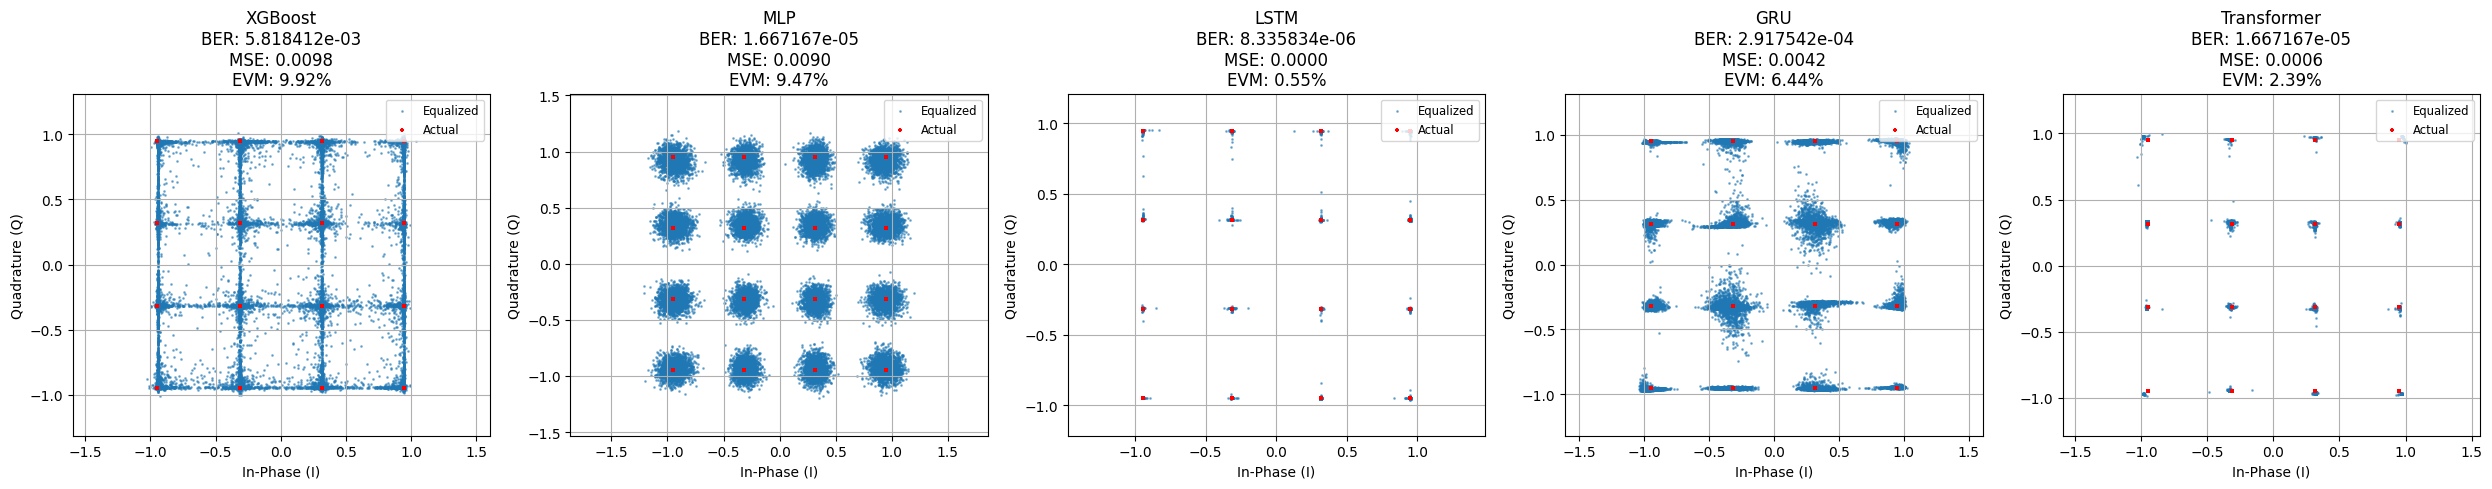


Model Performance Comparison (After Equalization)
Model        MSE          EVM (%)      R2 Score     BER             Bit Errors     
---------------------------------------------------------------------------------------------------------
XGBoost      0.0098       9.92         0.9902       5.818412e-03    698            
MLP          0.0090       9.47         0.9910       1.667167e-05    2              
LSTM         0.0000       0.55         1.0000       8.335834e-06    1              
GRU          0.0042       6.44         0.9958       2.917542e-04    35             
Transformer  0.0006       2.39         0.9994       1.667167e-05    2              


In [12]:
### Compare All Models ###
import matplotlib.pyplot as plt

# Collect all results - XGBoost first
all_results = [xgboost_results, mlp_results, lstm_results, gru_results, transformer_results]
model_names = ["XGBoost", "MLP", "LSTM", "GRU", "Transformer"]

# Create comparison plots - only showing After EQ
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, (results, name) in enumerate(zip(all_results, model_names)):
    # After equalization only
    axes[idx].scatter(results["eq_symbols"].real, results["eq_symbols"].imag, 
                     s=1, label='Equalized', alpha=0.5)
    axes[idx].scatter(results["actual_symbols"].real, results["actual_symbols"].imag, 
                     s=10, c='red', marker='+', label='Actual')
    axes[idx].set_title(
        f'{name}\nBER: {results["ber_after"]:.6e}\n'
        f'MSE: {results["mse_after"]:.4f}\n'
        f'EVM: {results["evm_after"]:.2f}%'
    )
    axes[idx].set_xlabel('In-Phase (I)')
    axes[idx].set_ylabel('Quadrature (Q)')
    axes[idx].legend(loc='upper right', fontsize='small')
    axes[idx].grid(True)
    axes[idx].axis('equal')

# plt.suptitle(f"{MODULATION_ORDER}QAM Model Comparison After Equalization", fontsize=16)
plt.tight_layout()

# Save as PDF for vector graphics
plt.savefig('model_comparison_constellation.pdf', format='pdf', bbox_inches='tight', dpi=300)
print("Figure saved as 'model_comparison_constellation.pdf'")

plt.show()

# Print comprehensive comparison table - After EQ only
print("\n" + "="*105)
print("Model Performance Comparison (After Equalization)")
print("="*105)
print(f"{'Model':<12} {'MSE':<12} {'EVM (%)':<12} {'R2 Score':<12} {'BER':<15} {'Bit Errors':<15}")
print("-"*105)
for results, name in zip(all_results, model_names):
    num_errors = results["bit_errors_after"]
    
    print(f"{name:<12} {results['mse_after']:<12.4f} {results['evm_after']:<12.2f} {results['r2_after']:<12.4f} "
          f"{results['ber_after']:<15.6e} {num_errors:<15d}")